# E01 — Bitstamp US night hourly drift

Methodology notebook for [`H08`](../../docs/research/R01-crypto/hypothesis/H08-day-trader-night-flattening.md)
and [`E01`](../../docs/research/R01-crypto/experiments/E01-bitstamp-us-night-hourly-drift.md).

| Field | Value |
|---|---|
| Research | R01-crypto |
| Hypothesis | H08 day-trader night flattening |
| Experiment | E01 |
| Preregistered | false (tape opened before this notebook was written) |
| Primary window | 21:00–00:00 `America/Los_Angeles` |
| Secondary window | 21:00–00:00 `America/New_York` |
| Source | Kaggle `mczielinski/bitcoin-historical-data` v685, Bitstamp 1-min BTCUSD |
| Cutoff | 2026-08-08 00:44 UTC |

The runnable method is the sibling script
`E01-bitstamp-us-night-hourly-drift.py`. This notebook executes it, then plots
hour-of-day means. Copy labeled `PRIMARY` / `SECONDARY` prints into the experiment
record; do not re-type numbers from an ad hoc session.


In [1]:
from pathlib import Path
import runpy

from IPython.display import display

HERE = Path.cwd().resolve()
script = HERE / "E01-bitstamp-us-night-hourly-drift.py"
if not script.is_file():
    script = HERE / "R01-crypto" / "E01-bitstamp-us-night-hourly-drift.py"
if not script.is_file():
    raise FileNotFoundError(
        "E01 methodology script not found; run from notebooks/R01-crypto or the Parallax root"
    )

ns = runpy.run_path(str(script), run_name="e01_method")
hourly = ns["main"]()
hourly.head()


research=R01 hypothesis=H08 experiment=E01
preregistered=False
kaggle_handle=mczielinski/bitcoin-historical-data
kaggle_version=685
source_csv=/Users/daniel/data/kaggle/datasets/mczielinski/bitcoin-historical-data/versions/685/btcusd_1-min_data.csv
sha256=7cc5764ca4307d0ed90400f0c1331fa1154c04f8a40187796e8ef6625a6dfece
retrieved_at=2026-08-08T04:23:40.014185+00:00
license=['CC-BY-SA-4.0']


minute_checks {'rows': 185805, 'nulls': 0, 'missing_minutes': 0, 'high_lt_low': 0, 'nonpositive_close': 0, 'ohlc_inconsistent': 0, 'zero_volume': 1241}
hours=3097 returns=3096
first_hour=2026-04-01 00:00:00+00:00 close=68252.00 minutes=60
last_hour=2026-08-08 00:00:00+00:00 close=64872.52 minutes=45
buy_and_hold=-0.04951474
pt_offsets=['-1 day, 17:00:00']
et_offsets=['-1 day, 20:00:00']
unconditional {'mean_bps': -0.07704691984210739, 'std_bps': 41.70158484770756, 'ann_vol': 0.3904390915296943, 'excess_kurtosis': 10.837395393977403}
month_end_closes
                              close  n_minutes
hour                                          
2026-04-30 23:00:00+00:00  76310.00         60
2026-05-31 23:00:00+00:00  73567.99         60
2026-06-30 23:00:00+00:00  58526.17         60
2026-07-31 23:00:00+00:00  62817.96         60
2026-08-08 00:00:00+00:00  64872.52         45
PRIMARY
PT 21:00-00:00
  n=387
  n_out=2709
  mean_bps=-0.115859
  mean_out_bps=-0.071502
  diff_bps=-0.044357
  ci

,open,high,low,close,volume,n_minutes,ret,log_ret,pt,et,hour_pt,hour_et,is_weekend_et
hour,,,,,,,,,,,,,
2026-04-01 00:00:00+00:00,68215.0,68269.0,67802.0,68252.0,68.042869,60,NaN,NaN,2026-03-31 17:00:00-07:00,2026-03-31 20:00:00-04:00,17,20,False
2026-04-01 01:00:00+00:00,68266.0,68300.0,67706.0,67731.0,47.664945,60,-0.007633,-0.007663,2026-03-31 18:00:00-07:00,2026-03-31 21:00:00-04:00,18,21,False
2026-04-01 02:00:00+00:00,67731.0,67850.0,67542.0,67605.0,112.392562,60,-0.001860,-0.001862,2026-03-31 19:00:00-07:00,2026-03-31 22:00:00-04:00,19,22,False
2026-04-01 03:00:00+00:00,67609.0,68184.0,67609.0,68108.0,32.202642,60,0.007440,0.007413,2026-03-31 20:00:00-07:00,2026-03-31 23:00:00-04:00,20,23,False
2026-04-01 04:00:00+00:00,68108.0,68402.0,67966.0,68237.0,37.061238,60,0.001894,0.001892,2026-03-31 21:00:00-07:00,2026-04-01 00:00:00-04:00,21,0,False


## Hour-of-day means

Primary night hours are 21–23 Pacific (shaded). Eastern 21–23 is the secondary copy of
the same three-hour window.


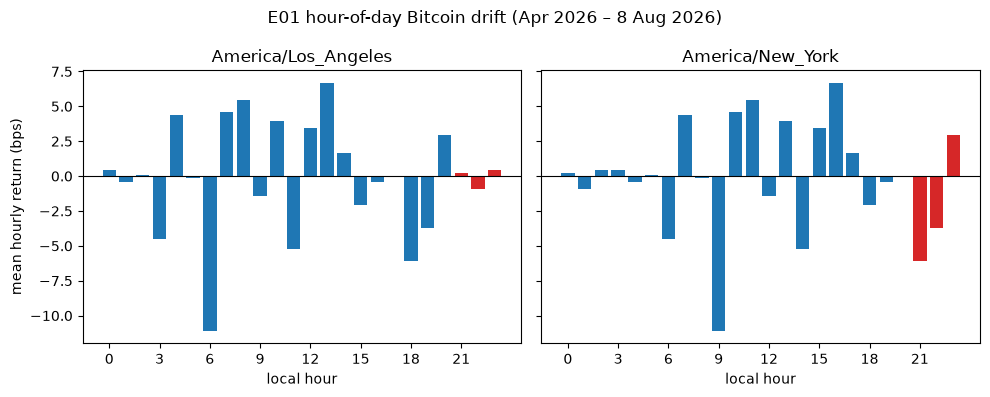

In [2]:
import matplotlib.pyplot as plt

def mean_bps(frame, hour_col):
    return frame.groupby(hour_col)["ret"].mean() * 1e4

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, col, title in (
    (axes[0], "hour_pt", "America/Los_Angeles"),
    (axes[1], "hour_et", "America/New_York"),
):
    series = mean_bps(hourly, col)
    colors = ["C3" if hour in ns["NIGHT_HOURS"] else "C0" for hour in series.index]
    ax.bar(series.index, series.values, color=colors)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel("local hour")
    ax.set_xticks(range(0, 24, 3))
axes[0].set_ylabel("mean hourly return (bps)")
fig.suptitle("E01 hour-of-day Bitcoin drift (Apr 2026 – 8 Aug 2026)")
fig.tight_layout()
display(fig)
plt.close(fig)


## Record

Paste `PRIMARY` and `SECONDARY` block values into
`docs/research/R01-crypto/experiments/E01-bitstamp-us-night-hourly-drift.md`.
Three-hour block rankings, cash-close, and crash-hour tables are exploratory and
must stay marked as such. This notebook cannot `advance` H08.
